**Project . Customer Segmentation - Clustering**

**Dataset:** `Mall_Customers.csv`

**Kaggle link:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data

**1.Setup**

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [3]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "Mall_Customers.csv"          # update path for a different dataset

**2.Load**

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
df.shape

(200, 5)

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**3. Exploratory Data Analysis (EDA)**

In [7]:
# save CustomerID to a list for later use
customer_id = df["CustomerID"]

In [8]:
customer_id.head(5)

0    1
1    2
2    3
3    4
4    5
Name: CustomerID, dtype: int64

In [9]:
# drop CustomerID column as it is not useful for modelling
df = df.drop(columns=["CustomerID"])

In [10]:
#basic dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [11]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [12]:
#check for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Gender
Female    112
Male       88
Name: count, dtype: int64
Age
32    11
35     9
19     8
31     8
30     7
49     7
23     6
40     6
36     6
27     6
Name: count, dtype: int64
Annual Income (k$)
54    12
78    12
48     6
60     6
62     6
63     6
71     6
87     6
19     4
20     4
Name: count, dtype: int64
Spending Score (1-100)
42    8
55    7
73    6
46    6
35    5
75    5
52    5
50    5
59    5
48    5
Name: count, dtype: int64


In [13]:
#check duplicates
duplicate_mask=df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


**Data Visualization**

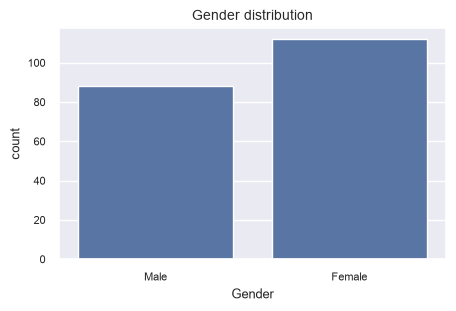

In [18]:
# gender distribution
plt.figure(figsize=(5,3))
sns.countplot(x='Gender',data=df)
plt.title("Gender distribution")
plt.show()

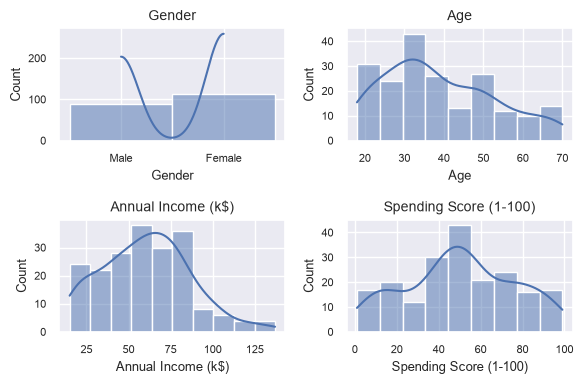

In [23]:
#histogram plot distribution
fig,axes = plt.subplots(2,2, figsize=(6,4))
axes = axes.flatten()

for i,col in enumerate(df.columns):
    sns.histplot(df[col],kde=True, ax=axes[i])
    axes[i].set_title(col)
    
plt.tight_layout()
plt.show()    


In [24]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

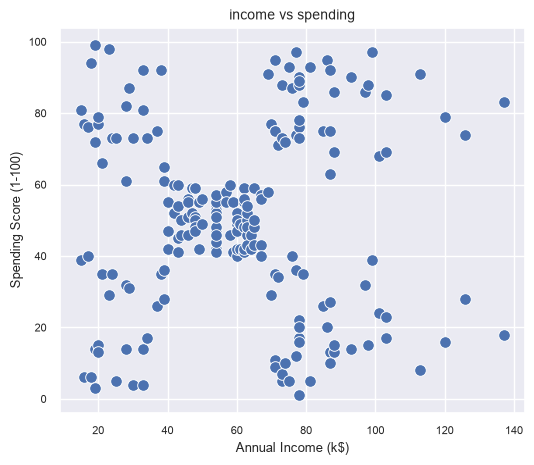

In [27]:
#scatter plot- income vs spending
plt.figure(figsize=(6,5))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df,
    s=70
)
plt.title("income vs spending")
plt.show()

**Inference: We can clearly see clusters in this plot**

**4.Data preprocessing**

In [28]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [30]:
#feature selection
columns_to_select = ["Annual Income (k$)","Spending Score (1-100)"]

X=df[columns_to_select]

In [31]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [33]:
# scale the features (K-means is distance-based)
scaler = StandardScaler()

X_scaled =scaler.fit_transform(X)

In [34]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

**5. Elbow Method - WCSS**

(Find best k value)

In [35]:
wcss = []
k_range = range(1,11)
print(*k_range)

1 2 3 4 5 6 7 8 9 10


In [36]:
wcss = []
k_range = range(1,11)

# Calculate inertia for each number of clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k,random_state=RANDOM_STATE)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

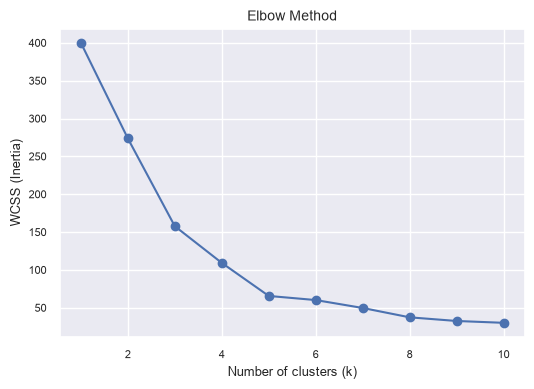

In [37]:
plt.figure(figsize=(6,4))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.show()

**Key observations:**
- Very steep drop from K = 1 → 2 → 3
- Still a noticeable improvement till K = 4
- After K = 5, the curve starts flattening
- From K = 6 onward, the reduction in WCSS is marginal

📌 This clear change in slope around K = 5 is the elbow point.

In [38]:
wcss

[400.0,
 273.6688866264201,
 157.7040081503595,
 109.22822707921344,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091,
 30.05932269404221]

**6. K-Means Clustering**

In [39]:
K_FINAL = 5

In [40]:
kmeans_final = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10
)

In [42]:
kmeans_final.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[[-0.

In [43]:
clusters = kmeans_final.predict(X_scaled)

In [44]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [45]:
#copy of original df
df_clusters= df.copy(deep=True)

In [46]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [47]:
df_clusters["clusters"]= clusters

In [49]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


In [50]:
df_clusters["CustomerID"] = customer_id

In [51]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5


**7. Evaluation**

In [52]:
k_means_score = silhouette_score(X_scaled, df_clusters["clusters"])
print("K-Means Clustering - Silhouette Score:", round(k_means_score, 3))

K-Means Clustering - Silhouette Score: 0.555


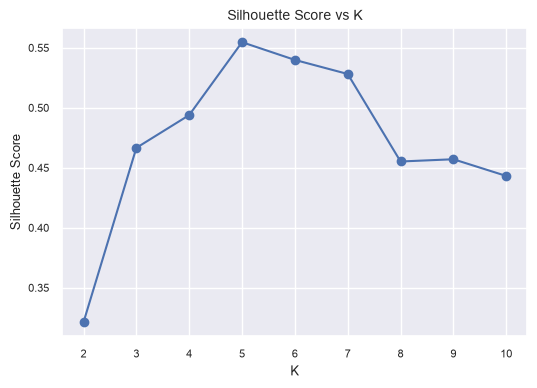

In [53]:
sil_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), sil_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

**8. Visualize clusters**

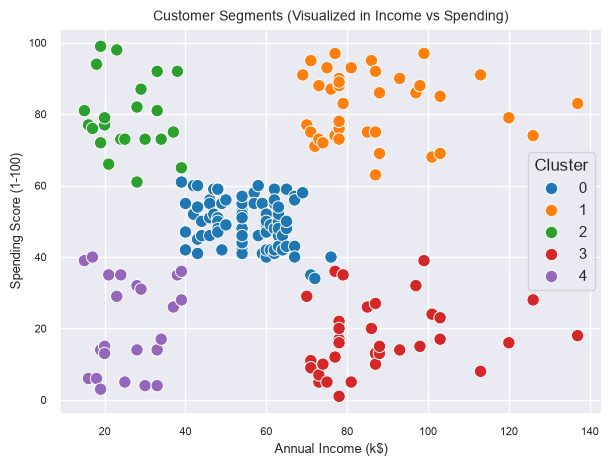

In [54]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=df_clusters["Annual Income (k$)"],
    y=df_clusters["Spending Score (1-100)"],
    hue=df_clusters["clusters"],
    palette="tab10",
    s=80
)

plt.title("Customer Segments (Visualized in Income vs Spending)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.show()

**9. Cluster Interpretation (Business Profiling)**

In [55]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [56]:
profile_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

cluster_sizes = df_clusters["clusters"].value_counts().sort_index()
cluster_profile_mean = df_clusters.groupby("clusters")[profile_cols].mean()
cluster_profile_median = df_clusters.groupby("clusters")[profile_cols].median()





print("Cluster Sizes:\n")
print(cluster_sizes)

print("Cluster Profile (Mean):\n")
display(cluster_profile_mean)

print("Cluster Profile (Median):\n")
display(cluster_profile_median)

Cluster Sizes:

clusters
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
Cluster Profile (Mean):



,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


Cluster Profile (Median):



,Age,Annual Income (k$),Spending Score (1-100)
clusters,,,
0,46.00,54.00,50.00
1,32.00,79.00,83.00
2,23.50,24.50,77.00
3,42.00,85.00,16.00
4,46.00,25.00,17.00


**10. Segment Assignment Function (for new customers)**

In [58]:
def assign_customer_segment(income_k, spending_score, scaler, model):
    new_point = pd.DataFrame(
        [[income_k, spending_score]],
        columns=["Annual Income (k$)", "Spending Score (1-100)"]
    )
    
    new_point_scaled = scaler.transform(new_point)
    cluster_id = model.predict(new_point_scaled)[0]
    return cluster_id

In [59]:
# Example usage
new_cluster = assign_customer_segment(
    income_k=60,
    spending_score=65,
    scaler=scaler,
    model=kmeans_final
)

print("\n✅ New customer assigned to cluster:", new_cluster)


✅ New customer assigned to cluster: 0


In [60]:
# Example usage
new_cluster = assign_customer_segment(
    income_k=34,
    spending_score=45,
    scaler=scaler,
    model=kmeans_final
)

print("\n✅ New customer assigned to cluster:", new_cluster)


✅ New customer assigned to cluster: 0
